#### In this notebook we use the cleaned DHS KR child files to look at long term trends in child malnutrition across East Africa.We focus on height for age (HAZ), which is a standard way to measure stunting. We combine all the KR files we cleaned earlier, keep the survey year and HAZ, and build one big table of children across Ethiopia, Kenya, Tanzania, and Uganda.Then we calculate the mean HAZ and the percent of children who are stunted (HAZ below -2) for each survey year and each country. Finally, we make simple line plots to see how stunting has changed over time in the four countries.

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


In [126]:
kr_files = [
    "Ethiopia_KR_1992_clean.csv",
    "Ethiopia_KR_1997_clean.csv",
    "Ethiopia_KR_2003_clean.csv",
    "Ethiopia_KR_2008_clean.csv",
    "Ethiopia_KR_2011_clean.csv",
    "Kenya_KR_89_clean.csv",
    "Kenya_KR_93_clean.csv",
    "Kenya_KR_98_clean.csv",
    "Kenya_KR_2003_clean.csv",
    "Kenya_KR_2009_clean.csv",
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
    "Tanzania_KR_92_clean.csv",
    "Tanzania_KR_96_clean.csv",
    "Tanzania_KR_99_clean.csv",
    "Tanzania_KR_2004_clean.csv",
    "Tanzania_KR_2010_clean.csv",
    "Tanzania_KR_2015_clean.csv",
    "Tanzania_KR_2022_clean.csv",
    "Uganda_KR_88_clean.csv",
    "Uganda_KR_95_clean.csv",
    "Uganda_KR_2001_clean.csv",
    "Uganda_KR_2006_clean.csv",
    "Uganda_KR_2011_clean.csv",
    "Uganda_KR_2016_clean.csv",
]

#### Here we loop over all the cleaned KR files.

For each file we:
- read the csv
- check that it has height for age and interview year
- keep only those two columns
- add a simple country label based on the file name
- stack all rows together into one DataFrame called child_data.


In [128]:
child_list = []

for fname in kr_files:
    df = pd.read_csv(fname)
    cols = df.columns
    
    # we only keep files that actually have HAZ and interview year
    if ("height for age SD per WHO" in cols) and ("interview year" in cols):
        # keep only the columns we need
        small = df[["height for age SD per WHO", "interview year"]].copy()
        
        # simple country name from the file name (first part before "_")
        country_name = fname.split("_")[0]
        small["country"] = country_name
        
        # rename so the column names are shorter to type later
        small = small.rename(columns={
            "height for age SD per WHO": "haz",
            "interview year": "survey_year",
        })
        
        child_list.append(small)

# put everything into one table
child_data = pd.concat(child_list, ignore_index=True)

child_data.head()


,haz,survey_year,country
0,-226.0,2003,Ethiopia
1,-379.0,2003,Ethiopia
2,-301.0,2003,Ethiopia
3,-300.0,2003,Ethiopia
4,-83.0,2003,Ethiopia


##### Next we clean up the combined child table a little.

We:
- drop rows where HAZ is missing
- create a stunting flag where haz < -2


In [130]:
# drop missing HAZ
child_data = child_data.dropna(subset=["haz"])

# stunting flag: True if HAZ < -2
child_data["is_stunted"] = child_data["haz"] < -2

child_data[["country", "survey_year", "haz", "is_stunted"]].head()


,country,survey_year,haz,is_stunted
0,Ethiopia,2003,-226.0,True
1,Ethiopia,2003,-379.0,True
2,Ethiopia,2003,-301.0,True
3,Ethiopia,2003,-300.0,True
4,Ethiopia,2003,-83.0,True


#### Next step is to e group b `county` an `survey_yer` and calculate:
- the mean HAZ
- the stunting rate (share of children with HAZ below -2)
- the number of children in each group (just for context)

We also convert the stunting rate into a percentage so it is easier to read.



In [132]:
summary = (
    child_data
    .groupby(["country", "survey_year"])
    .agg(
        mean_haz=("haz", "mean"),
        stunting_rate=("is_stunted", "mean"),
        n_children=("haz", "size"),
    )
    .reset_index()
)

summary["stunting_percent"] = summary["stunting_rate"] * 100

summary.head()


,country,survey_year,mean_haz,stunting_rate,n_children,stunting_percent
0,Ethiopia,2003,681.782824,0.762023,10480,76.202290
1,Ethiopia,2008,1.683302,0.786900,8977,78.689986
2,Ethiopia,2011,-44.234101,0.829107,5126,82.910652
3,Kenya,2008,692.783447,0.732021,2489,73.202089
4,Kenya,2009,510.431523,0.767078,3001,76.707764


In [209]:
# put all countries / years together
children_all_years = child_data.copy()

# drop rows with missing HAZ
children_all_years = children_all_years.dropna(subset=["haz"]).copy()

# stunted if HAZ < -2
children_all_years["is_stunted"] = children_all_years["haz"] < -2

# quick check of what we got
children_all_years[["country", "survey_year"]].drop_duplicates().sort_values(
    ["country", "survey_year"]
)

stunting_trend["stunting_percent"] = stunting_trend["stunted_rate"] * 100
stunting_trend.head()


,country,survey_year,stunted_rate,n_children,stunting_percent
0,Ethiopia,2003,0.762023,10480,76.202290
1,Ethiopia,2008,0.786900,8977,78.689986
2,Ethiopia,2011,0.829107,5126,82.910652
3,Kenya,2008,0.732021,2489,73.202089
4,Kenya,2009,0.767078,3001,76.707764


In [205]:
stunting_trend = (
    children_all_years
    .groupby(["country", "survey_year"])["is_stunted"]
    .agg(stunted_rate="mean", n_children="count")
    .reset_index()
    .sort_values(["country", "survey_year"])
)

stunting_trend.head()


,country,survey_year,stunted_rate,n_children
0,Ethiopia,2003,0.762023,10480
1,Ethiopia,2008,0.786900,8977
2,Ethiopia,2011,0.829107,5126
3,Kenya,2008,0.732021,2489
4,Kenya,2009,0.767078,3001


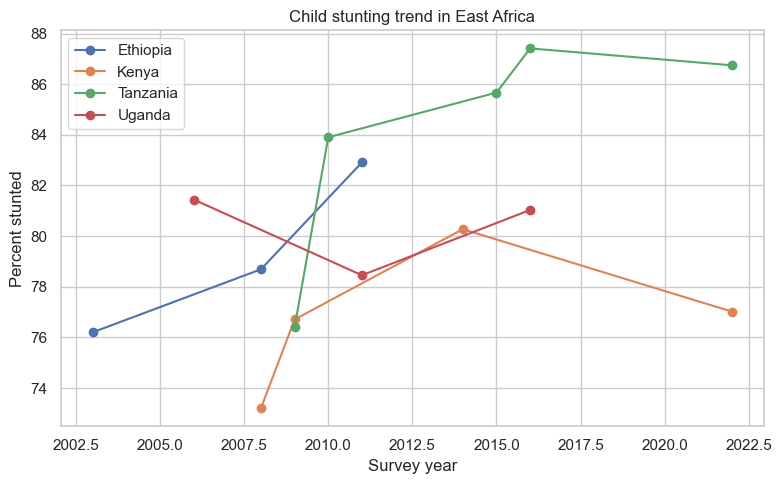

In [211]:
plt.figure(figsize=(8, 5))
for c in sorted(stunting_trend["country"].unique()):
    sub= stunting_trend[stunting_trend["country"] == c]
    plt.plot(sub["survey_year"], sub["stunting_percent"], marker ="o", label=c)

plt.xlabel("Survey year")
plt.ylabel("Percent stunted")
plt.title("Child stunting trend in East Africa")
plt.legend()
plt.tight_layout()
plt.show()


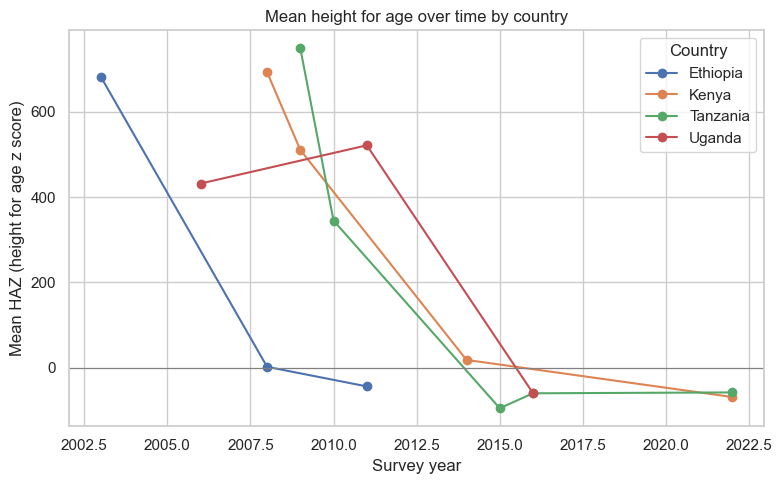

In [150]:
plt.figure(figsize=(8, 5))

countries = summary["country"].unique()

for country in countries:
    sub = summary[summary["country"] == country]
    plt.plot(sub["survey_year"], sub["mean_haz"], marker="o", label=country)

plt.axhline(0, color="gray", linewidth=0.8)  # zero line for reference

plt.xlabel("Survey year")
plt.ylabel("Mean HAZ (height for age z score)")
plt.title("Mean height for age over time by country")
plt.legend(title="Country")
plt.tight_layout()
plt.show()



KeyError: 'stunting_percent'

<Figure size 800x500 with 0 Axes>

#### Next we look at the percent of children who are stunted over time.This is easier to interpret because it shows something like “X percent of children are stunted in this country and year” instead of raw z scores.


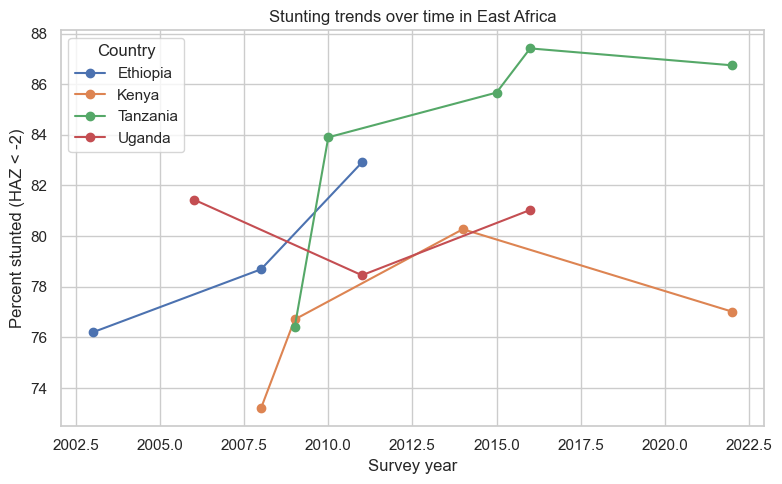

In [152]:
plt.figure(figsize=(8, 5))

for country in countries:
    sub = summary[summary["country"] == country]
    plt.plot(sub["survey_year"], sub["stunting_percent"], marker="o", label=country)

plt.xlabel("Survey year")
plt.ylabel("Percent stunted (HAZ < -2)")
plt.title("Stunting trends over time in East Africa")
plt.legend(title="Country")
plt.tight_layout()
plt.show()


##### Here we make a bar chart.For each country we plot the percent of children who are stunted in each survey year. This makes it easier to see which years are higher or lower and how the pattern differs across Ethiopia, Kenya, Tanzania, and Uganda.


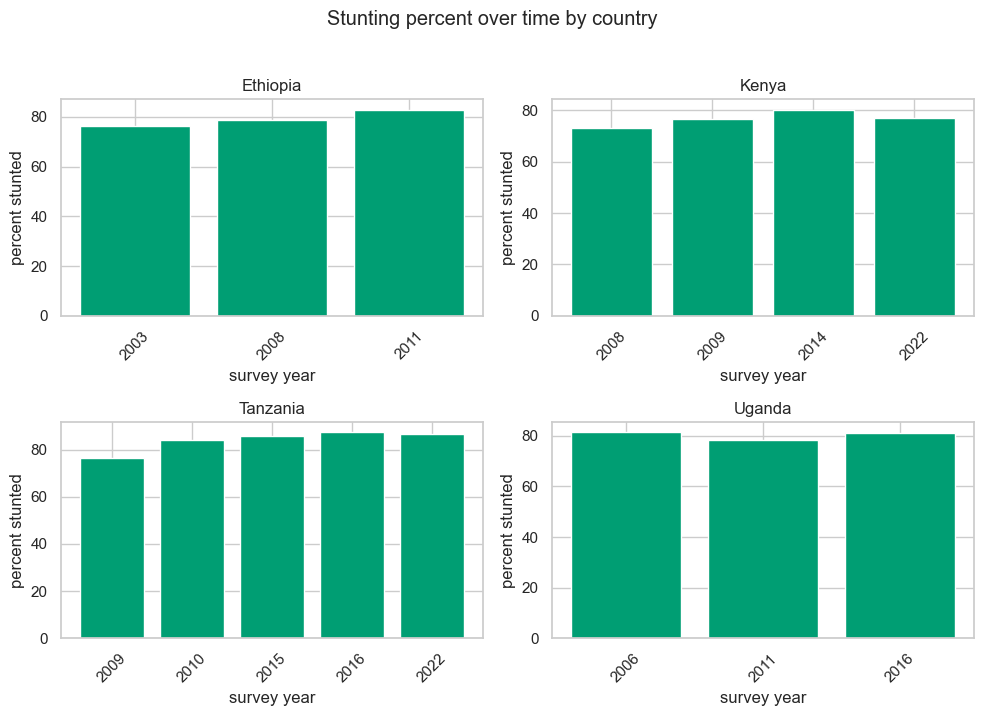

In [156]:
# bar chart of stunting over time, one small plot per country

countries = summary["country"].unique()

plt.figure(figsize=(10, 7))

for i, c in enumerate(countries):
    plt.subplot(2, 2, i + 1)
    
    # keep rows for this country and sort by year
    sub = summary[summary["country"] == c].copy()
    sub = sub.sort_values("survey_year")
    
    x_vals = sub["survey_year"].astype(str)
    y_vals = sub["stunting_percent"]
    
    # bright colorblind safe color

    plt.bar(x_vals, y_vals, color="#009E73")
    
    plt.title(c)
    plt.xlabel("survey year")
    plt.ylabel("percent stunted")
    plt.xticks(rotation=45)

plt.suptitle("Stunting percent over time by country", y=1.02)
plt.tight_layout()
plt.show()



##### In this section we switch and look at how stunting varies across wealth groups. This helps us see whether children in poorer households are consistently more affected by malnutrition.

In [158]:
sns.set_theme(style="whitegrid")

# most recent KR file for each country
recent_files = {
    "Ethiopia": "Ethiopia_KR_2011_clean.csv",
    "Kenya": "Kenya_KR_2022_clean.csv",
    "Tanzania": "Tanzania_KR_2022_clean.csv",
    "Uganda": "Uganda_KR_2016_clean.csv",
}

# we will collect one small table per country
rows = []

for country, fname in recent_files.items():
    df = pd.read_csv(fname)
    cols = df.columns.tolist()

    # check that we have the columns we need
    if "height for age SD per WHO" not in cols:
        continue
    if "wealth_quartile" not in cols:
        continue

    # drop rows with missing values
    mini = df[["height for age SD per WHO", "wealth_quartile"]].dropna()

    # flag stunted children (HAZ < -2)
    mini["is_stunted"] = mini["height for age SD per WHO"] < -2

    # percent stunted by wealth quartile
    grouped = mini.groupby("wealth_quartile")["is_stunted"].mean() * 100

    for wq, pct in grouped.items():
        rows.append({
            "country": country,
            "wealth_quartile": wq,
            "stunting_percent": pct
        })

stunting_wealth_recent = pd.DataFrame(rows)
stunting_wealth_recent.head()


,country,wealth_quartile,stunting_percent
0,Ethiopia,1,80.345040
1,Ethiopia,2,85.221675
2,Ethiopia,3,87.317073
3,Ethiopia,4,84.929757
4,Ethiopia,5,80.238971


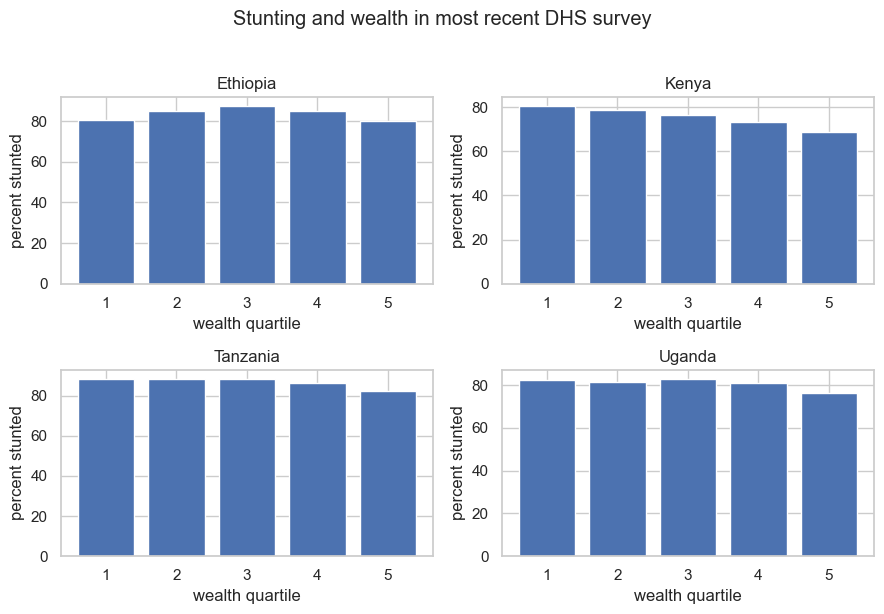

In [159]:
# order for the x-axis so it is not scrambled
quartile_order = sorted(stunting_wealth_recent["wealth_quartile"].unique())

plt.figure(figsize=(9, 6))

# one subplot per country (2x2 grid)
countries = ["Ethiopia", "Kenya", "Tanzania", "Uganda"]

for i in range(len(countries)):
    c = countries[i]
    plt.subplot(2, 2, i + 1)

    sub = stunting_wealth_recent[stunting_wealth_recent["country"] == c]

    plt.bar(sub["wealth_quartile"], sub["stunting_percent"])
    plt.xlabel("wealth quartile")
    plt.ylabel("percent stunted")
    plt.title(c)

plt.suptitle("Stunting and wealth in most recent DHS survey", y=1.02)
plt.tight_layout()
plt.show()


#### We flagged children as stunted when their height-for-age z score (HAZ) was below -2. To simplify long-term analysis, survey years were grouped into decades.  For each country and decade, we calculated the number of children observed and the average stunting rate. The stunting rate was converted into a percentage to make results easier to interpret The next step is creating a heatmap, showing how stunting has shifted across countries over time.  This visualization highlights both regional differences and long-term progress in reducing child malnutrition.  


In [162]:
children_list = []

for fname in kr_files:
    df = pd.read_csv(fname)
    
    # get country name from file name, for example "Kenya_KR_2014_clean.csv" -> "Kenya"
    country_name = fname.split("_")[0]
    
    # use the interview year column
    if "interview year" in df.columns:
        year_col = "interview year"
    elif "interview_year" in df.columns:
        year_col = "interview_year"
    else:
        continue
    
    # find the height for age Z score column
    haz_col = None
    if "height for age SD per WHO" in df.columns:
        haz_col = "height for age SD per WHO"
    elif "z_height_for_age" in df.columns:
        haz_col = "z_height_for_age"
    elif "haz_height_for_age_z" in df.columns:
        haz_col = "haz_height_for_age_z"
    
    if haz_col is None:
        continue
    
    # keep only what we need from this file
    tmp = df[[year_col, haz_col]].copy()
    tmp = tmp.rename(columns={year_col: "survey_year", haz_col: "haz"})
    tmp["country"] = country_name
    
    children_list.append(tmp)

# stack everything into one data frame
children_all = pd.concat(children_list, ignore_index=True)

children_all.head()


,survey_year,haz,country
0,2003,-226.0,Ethiopia
1,2003,-379.0,Ethiopia
2,2003,-301.0,Ethiopia
3,2003,-300.0,Ethiopia
4,2003,-83.0,Ethiopia


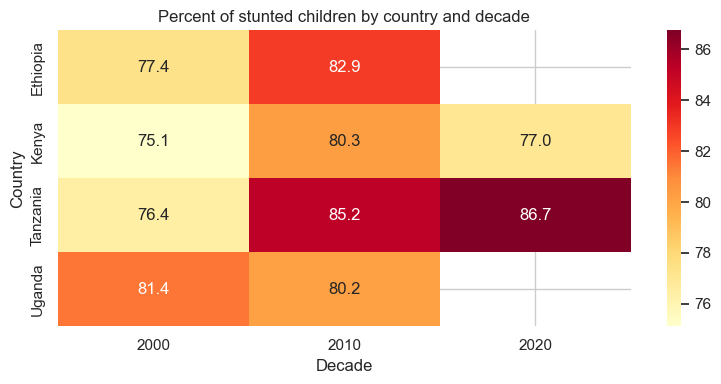

In [163]:
# stunting flag
children_all["is_stunted"] = children_all["haz"] < -2

# make a simple decade variable, for example 1992 -> 1990
def make_decade(y):
    return int(y // 10) * 10

children_all = children_all.dropna(subset=["survey_year", "haz"]).copy()
children_all["decade"] = children_all["survey_year"].apply(make_decade)

# group by country and decade
stunting_decade = (
    children_all
    .groupby(["country", "decade"])
    .agg(
        n_children=("haz", "size"),
        stunting_rate=("is_stunted", "mean"),
    )
    .reset_index()
)

# convert to percent
stunting_decade["stunting_percent"] = stunting_decade["stunting_rate"] * 100

# reshape for heatmap
heat_table = stunting_decade.pivot(
    index="country",
    columns="decade",
    values="stunting_percent"
)

plt.figure(figsize=(8, 4))

sns.heatmap(
    heat_table,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Percent of stunted children by country and decade")
plt.xlabel("Decade")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

##### The plan is to clean up the HAZ values a little before I calculate the stunting rates.  Main idea is to drop missing HAZ and get rid of extreme values that probably are not real kids.  Then I rebuild the country by year summary so the plots use the cleaned version.

In [165]:
# dropping rows where HAZ is missing just to be safe
child_data = child_data.dropna(subset=["haz"]).copy()

# keeping only HAZ in a normal range (this follows WHO style cutoffs)
child_data = child_data[child_data["haz"].between(-6, 6)].copy()

# redo the stunting flag based on cleaned HAZ
child_data["is_stunted"] = child_data["haz"] < -2

# rebuild the summary table by country and survey year
summary = (
    child_data
    .groupby(["country", "survey_year"])
    .agg(
        mean_haz=("haz", "mean"),
        stunting_rate=("is_stunted", "mean"),
        n_children=("haz", "size"),
    )
    .reset_index()
)

# convert to percent so it is easier to read in plots
summary["stunting_percent"] = summary["stunting_rate"] * 100

summary.sort_values(["country", "survey_year"]).head()


,country,survey_year,mean_haz,stunting_rate,n_children,stunting_percent
0,Ethiopia,2003,0.290909,0.278788,165,27.878788
1,Ethiopia,2008,-0.136612,0.349727,183,34.972678
2,Ethiopia,2011,-0.464912,0.324561,114,32.456140
3,Kenya,2008,2.078431,0.098039,51,9.803922
4,Kenya,2009,1.025000,0.175000,40,17.500000


##### Here I am going to load CRU climate data for each country Next I bring in the CRU temperature data.

In [167]:
# list of climate files and the country name they belong to
climate_files = [
    ("Ethiopia_CRU_temp_1901_2024.csv", "Ethiopia"),
    ("Kenya_CRU_temp_1901_2024.csv", "Kenya"),
    ("Tanzania_CRU_temp_1901_2024.csv", "Tanzania"),
    ("Uganda_CRU_temp_1901_2024.csv", "Uganda"),
]

climate_list = []

for fname, country_name in climate_files:
    clim = pd.read_csv(fname)
    
    # keeping only the year and annual mean temperature
    tmp = clim[["YEAR", "ANN"]].copy()
    tmp = tmp.rename(columns={"YEAR": "year", "ANN": "mean_temp_c"})
    tmp["country"] = country_name
    
    climate_list.append(tmp)

climate_all = pd.concat(climate_list, ignore_index=True)

# finding the range of years where I have DHS surveys
min_year = summary["survey_year"].min()
max_year = summary["survey_year"].max()

# keeping only climate rows inside that range
climate_overlap = climate_all[
    climate_all["year"].between(min_year, max_year)
].copy()

climate_overlap.sort_values(["country", "year"]).head()


,year,mean_temp_c,country
102,2003,23.3,Ethiopia
103,2004,23.3,Ethiopia
104,2005,23.3,Ethiopia
105,2006,23.3,Ethiopia
106,2007,23.1,Ethiopia


#### Matching climate years to the DHS survey years. CRU goes back to 1901, but I only care about the years where I actually have a DHS survey. I use the minimum and maximum survey years to slice the climate data down to that range.

In [169]:
# finding the range of years where I have DHS surveys
min_year = summary["survey_year"].min()
max_year = summary["survey_year"].max()

# keeping only climate rows inside that range
climate_overlap = climate_all[
    climate_all["year"].between(min_year, max_year)
].copy()

# just looking at a few rows to make sure it worked
climate_overlap.sort_values(["country", "year"]).head()


,year,mean_temp_c,country
102,2003,23.3,Ethiopia
103,2004,23.3,Ethiopia
104,2005,23.3,Ethiopia
105,2006,23.3,Ethiopia
106,2007,23.1,Ethiopia


#### Here the plan is to match the DHS country year table with the CRU country year table.The key is country and year. After the merge I have one table that has stunting and mean temperature in the same place.


In [176]:
# make a copy of the DHS summary and add a plain year column
dhs_for_merge = summary.copy()
dhs_for_merge["year"] = dhs_for_merge["survey_year"].astype(int)

# merge DHS summary with climate by country and year
merged = pd.merge(
    dhs_for_merge,
    climate_overlap,
    on=["country", "year"],
    how="left"
)

merged.head()


,country,survey_year,mean_haz,stunting_rate,n_children,stunting_percent,year,mean_temp_c
0,Ethiopia,2003,0.290909,0.278788,165,27.878788,2003,23.3
1,Ethiopia,2008,-0.136612,0.349727,183,34.972678,2008,23.0
2,Ethiopia,2011,-0.464912,0.324561,114,32.456140,2011,23.2
3,Kenya,2008,2.078431,0.098039,51,9.803922,2008,25.2
4,Kenya,2009,1.025000,0.175000,40,17.500000,2009,25.8


In [178]:
merged_sorted = merged.sort_values(["country", "year"])

change = (
    merged_sorted
    .groupby("country")
    .agg(
        first_year=("year", "first"),
        last_year=("year", "last"),
        stunting_first=("stunting_percent", "first"),
        stunting_last=("stunting_percent", "last"),
        temp_first=("mean_temp_c", "first"),
        temp_last=("mean_temp_c", "last"),
    )
    .reset_index()
)

change["change_stunting"] = change["stunting_last"] - change["stunting_first"]
change["change_temp"] = change["temp_last"] - change["temp_first"]

change


,country,first_year,last_year,stunting_first,stunting_last,temp_first,temp_last,change_stunting,change_temp
0,Ethiopia,2003,2011,27.878788,32.456140,23.3,23.2,4.577352,-0.1
1,Kenya,2008,2022,9.803922,31.826742,25.2,25.5,22.022820,0.3
2,Tanzania,2009,2022,27.272727,29.896907,23.0,22.9,2.624180,-0.1
3,Uganda,2006,2016,33.333333,25.619835,23.9,23.6,-7.713499,-0.3


In [180]:
# putting each survey year into a simple temperature group
merged["temp_group"] = pd.qcut(
    merged["mean_temp_c"],
    q=3,
    labels=["cooler years", "medium years", "warmer years"]
)

merged[["country", "year", "mean_temp_c", "temp_group", "stunting_percent"]].head()


,country,year,mean_temp_c,temp_group,stunting_percent
0,Ethiopia,2003,23.3,medium years,27.878788
1,Ethiopia,2008,23.0,cooler years,34.972678
2,Ethiopia,2011,23.2,cooler years,32.456140
3,Kenya,2008,25.2,warmer years,9.803922
4,Kenya,2009,25.8,warmer years,17.500000


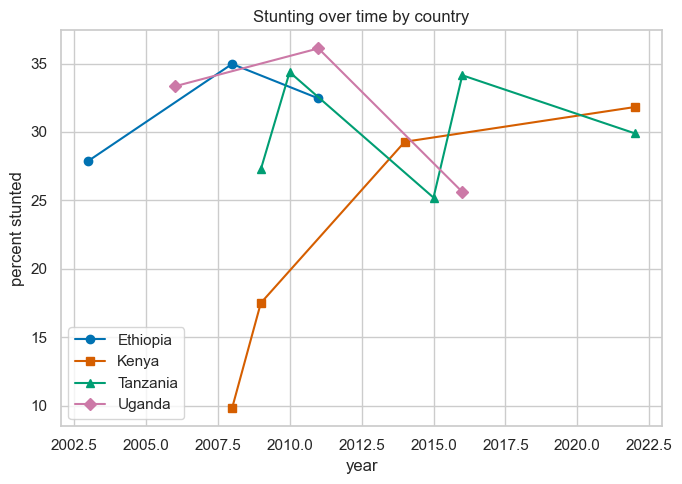

In [182]:
plt.figure(figsize=(7, 5))

# simple color blind friendly colors
country_colors = {
    "Ethiopia": "#0072B2",   # blue
    "Kenya": "#D55E00",      # orange
    "Tanzania": "#009E73",   # green
    "Uganda": "#CC79A7",     # purple
}

# different markers so you can tell them apart even in grey
country_markers = {
    "Ethiopia": "o",
    "Kenya": "s",
    "Tanzania": "^",
    "Uganda": "D",
}

for c in sorted(merged["country"].unique()):
    sub = merged[merged["country"] == c].sort_values("year")
    
    plt.plot(
        sub["year"],
        sub["stunting_percent"],
        marker=country_markers[c],
        color=country_colors[c],
        label=c,
    )

plt.xlabel("year")
plt.ylabel("percent stunted")
plt.title("Stunting over time by country")
plt.legend()
plt.tight_layout()
plt.show()



#### Inequality across all the countries by weallth group. In this section, the plan is to use the most recent DHS survey and compare children HAZ levels acrosss all wealth groups/wealth quantiles. This will help us analyze and see whether there is a gap between the rich and poor.

In [191]:
stunting_trend = (
    children_all_years
    .groupby(["country", "survey_year"])["is_stunted"]
    .agg(stunted_rate="mean", n_children="count")
    .reset_index()
    .sort_values(["country", "survey_year"])
)

stunting_trend.head()


,country,survey_year,stunted_rate,n_children
0,Ethiopia,2003,0.762023,10480
1,Ethiopia,2008,0.786900,8977
2,Ethiopia,2011,0.829107,5126
3,Kenya,2008,0.732021,2489
4,Kenya,2009,0.767078,3001


In [193]:
# find and pick the latest survey year for all 4 countries.
latest_years =(
    child_data
    .groupby("country")["survey_year"]
    .max()
    .reset_index()
)
latest_years

# we are using rows from the most recent surveys from each country
latest_survey = pd.merge(
    child_data,
    latest_years,
    on = ["country", "survey_year"],
    how ="inner"
)

In [195]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=latest_survey,
    x="wealth_quintile",
    y="haz",
    hue = "country"
)

plt.xlabel("wealth quintile")
plt.yalabel("child HAZ")
plt.title ("Child HAZ by wealth quantile in recent survey per Region")
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `wealth_quintile` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

In [189]:
child_data.columns


Index(['haz', 'survey_year', 'country', 'is_stunted'], dtype='object')